# Lab 4 Assignment
## Data Quality Assessment & Preprocessing on Netflix Dataset

## Task 1: Identify data quality issues in the dataset
In this task, I inspect the dataset structure, data types, missing values, and duplicate records.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("/Users/saraalsharabi/Desktop/lab4/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [5]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

### Task 1 Explanation
The dataset contains missing values in several columns such as `director`, `cast`, `country`, `date_added`, `rating`, and `duration`.  
Also, the `date_added` column is stored as an object and should be converted to datetime format.  
No duplicate records were found in the dataset.

## Data Type Correction
The `date_added` column should be converted from object to datetime.

In [7]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

### Explanation
The `date_added` column was converted to datetime format to ensure that the data type matches the meaning of the column.

## Task 2: Apply one missing value strategy and explain why
In this task, I use one missing value strategy only: Remove Records.

In [9]:
df_remove = df.dropna()

In [10]:
print("Shape before removing missing values:", df.shape)
print("Shape after removing missing values:", df_remove.shape)

Shape before removing missing values: (8807, 12)
Shape after removing missing values: (5328, 12)


In [11]:
df_remove.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### Task 2 Explanation
Missing values were handled using the **Remove Records** strategy (`dropna`).  
This strategy was chosen to follow the method demonstrated in the lab.  
It is also more suitable here than mean or median imputation because most missing values were found in categorical columns such as `director`, `cast`, and `country`, where mean and median cannot be applied.

## Task 3: Detect and handle outliers using IQR
To apply IQR, we need numerical features.  
The dataset already contains `release_year`, and we will extract a numerical feature from `duration`.

In [12]:
df_remove = df_remove.copy()
df_remove["duration_num"] = df_remove["duration"].str.extract(r"(\d+)").astype(float)
df_remove[["duration", "duration_num"]].head()

,duration,duration_num
7,125 min,125.0
8,9 Seasons,9.0
9,104 min,104.0
12,127 min,127.0
24,166 min,166.0


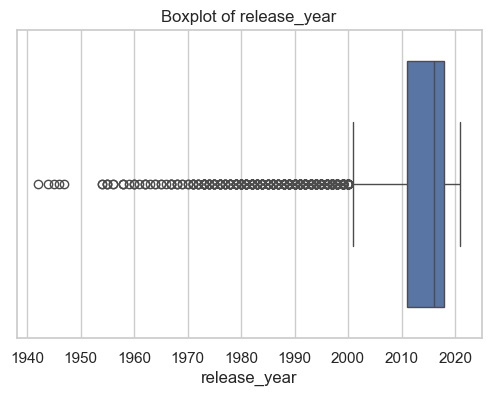

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_remove["release_year"])
plt.title("Boxplot of release_year")
plt.show()

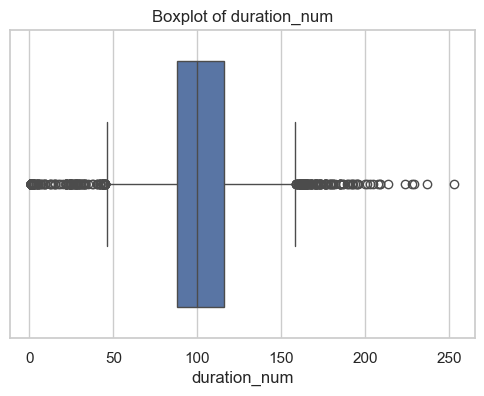

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_remove["duration_num"])
plt.title("Boxplot of duration_num")
plt.show()

In [15]:
Q1 = df_remove["release_year"].quantile(0.25)
Q3 = df_remove["release_year"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_release_year = df_remove[
    (df_remove["release_year"] < lower) | (df_remove["release_year"] > upper)
]

print("Number of outliers in release_year:", outliers_release_year.shape[0])

Number of outliers in release_year: 473


In [16]:
Q1_d = df_remove["duration_num"].quantile(0.25)
Q3_d = df_remove["duration_num"].quantile(0.75)
IQR_d = Q3_d - Q1_d

lower_d = Q1_d - 1.5 * IQR_d
upper_d = Q3_d + 1.5 * IQR_d

outliers_duration = df_remove[
    (df_remove["duration_num"] < lower_d) | (df_remove["duration_num"] > upper_d)
]

print("Number of outliers in duration_num:", outliers_duration.shape[0])

Number of outliers in duration_num: 379


In [17]:
df_no_outliers = df_remove[
    (df_remove["release_year"] >= lower) & (df_remove["release_year"] <= upper) &
    (df_remove["duration_num"] >= lower_d) & (df_remove["duration_num"] <= upper_d)
]

In [18]:
print("Shape before removing outliers:", df_remove.shape)
print("Shape after removing outliers:", df_no_outliers.shape)

Shape before removing outliers: (5328, 13)
Shape after removing outliers: (4542, 13)


### Task 3 Explanation
Outliers were detected and handled using the IQR method.  
Values outside the lower and upper bounds were considered outliers and removed from the dataset.

## Task 4: Normalize numerical features using both Min-Max and Z-score
In this task, I normalize the numerical features `release_year` and `duration_num`.

In [19]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
df_minmax = df_no_outliers[["release_year", "duration_num"]].copy()
df_minmax[["release_year", "duration_num"]] = minmax_scaler.fit_transform(
    df_minmax[["release_year", "duration_num"]]
)

df_minmax.head()

,release_year,duration_num
9,1.00,0.517857
12,1.00,0.723214
27,0.45,0.508929
28,0.60,0.455357
29,0.60,0.535714


In [20]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()
df_zscore = df_no_outliers[["release_year", "duration_num"]].copy()
df_zscore[["release_year", "duration_num"]] = zscore_scaler.fit_transform(
    df_zscore[["release_year", "duration_num"]]
)

df_zscore.head()

,release_year,duration_num
9,1.309886,0.115124
12,1.309886,1.210138
27,-1.170013,0.067515
28,-0.493677,-0.218141
29,-0.493677,0.210343


### Task 4 Explanation
Min-Max normalization scales the values to a range between 0 and 1.  
Z-score normalization standardizes the values around mean 0 and standard deviation 1.

## Task 5: Apply PCA only if the numerical features show a correlation
Before applying PCA, I first check the correlation between numerical features.

In [21]:
df_zscore.corr()

,release_year,duration_num
release_year,1.00000,-0.17082
duration_num,-0.17082,1.00000


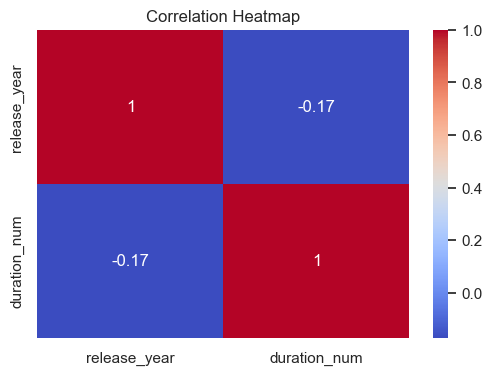

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(df_zscore.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Task 5 Explanation
The correlation between `release_year` and `duration_num` is weak to moderate, not strong.  
Therefore, PCA was not applied because the assignment requires PCA only if numerical features show a correlation strong enough to justify dimensionality reduction.

## Final Conclusion
In this assignment, the Netflix dataset was assessed for data quality issues.  
Missing values were handled using the Remove Records strategy.  
Outliers were detected and removed using IQR.  
Numerical features were normalized using both Min-Max and Z-score methods.  
Finally, PCA was not applied because the numerical features did not show a strong correlation.